In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/thiagosoto/titanic/train_and_test2.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [5]:
dataframe = pd.read_csv('/kaggle/input/datasets/thiagosoto/titanic/train_and_test2.csv')


In [6]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [7]:
dataframe.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [8]:
df= dataframe.drop(columns=['Passengerid','zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14','zero.15','zero.16','zero.17','zero.18'])

In [9]:
df

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,2urvived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0
...,...,...,...,...,...,...,...,...
1304,28.0,8.0500,0,0,0,3,2.0,0
1305,39.0,108.9000,1,0,0,1,0.0,0
1306,38.5,7.2500,0,0,0,3,2.0,0
1307,28.0,8.0500,0,0,0,3,2.0,0


In [12]:
train = df.groupby('Sex')['2urvived'].mean()
train

Sex
0    0.1293
1    0.5000
Name: 2urvived, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

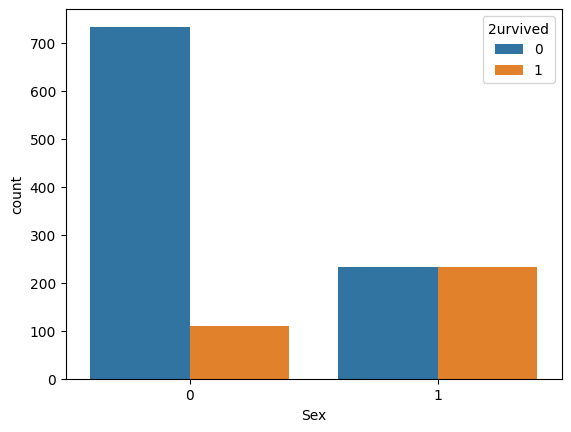

In [16]:
import seaborn as sns
sns.countplot(x='Sex', hue='2urvived', data=df)

In [18]:
df['Fare'].value_counts()

Fare
8.0500     60
13.0000    59
7.7500     55
26.0000    50
7.8958     49
           ..
12.7375     1
45.5000     1
7.5750      1
7.5792      1
7.7208      1
Name: count, Length: 281, dtype: int64

<Axes: xlabel='Age', ylabel='count'>

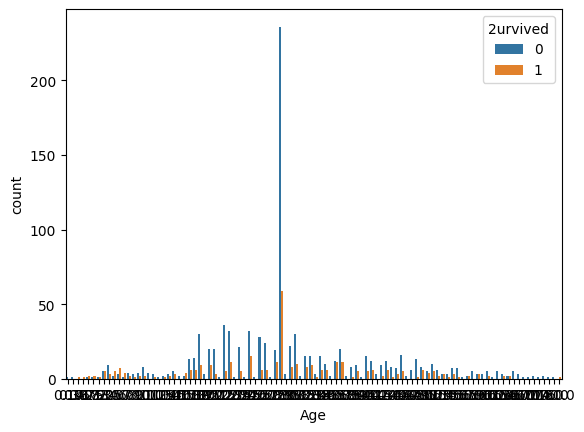

In [21]:
sns.countplot(x='Age', hue='2urvived', data=df)

<Axes: xlabel='sibsp', ylabel='count'>

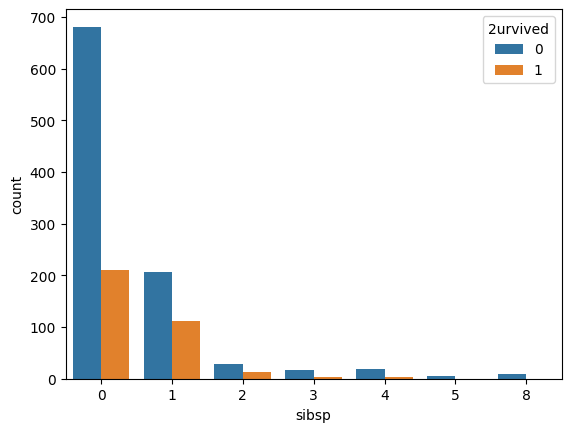

In [22]:
sns.countplot(x='sibsp', hue='2urvived', data=df)

<Axes: xlabel='Fare', ylabel='count'>

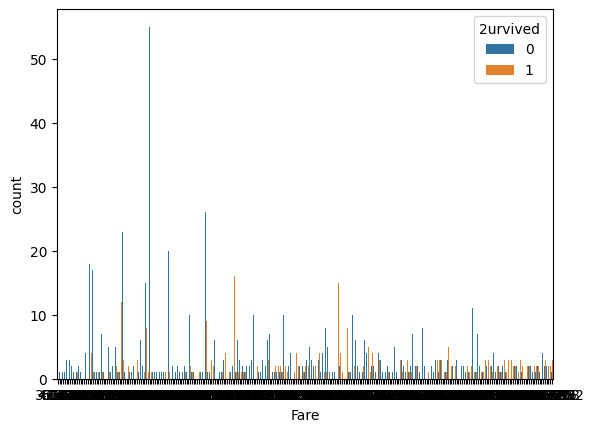

In [23]:
sns.countplot(x='Fare', hue='2urvived', data=df)

<Axes: xlabel='Age', ylabel='Count'>

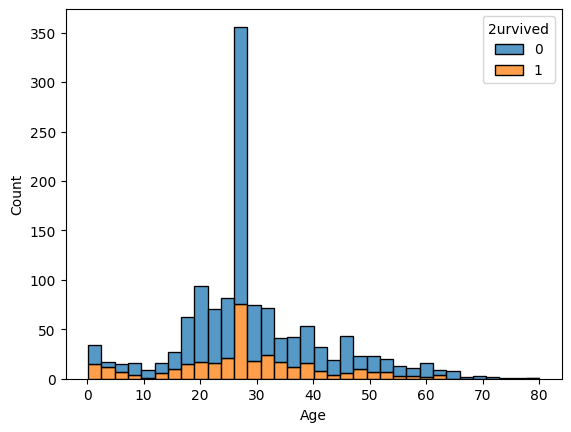

In [25]:
sns.histplot(data=df, x='Age', hue='2urvived', multiple='stack')

In [26]:

df.isna().sum()

Age         0
Fare        0
Sex         0
sibsp       0
Parch       0
Pclass      0
Embarked    2
2urvived    0
dtype: int64

<Axes: xlabel='Embarked', ylabel='Count'>

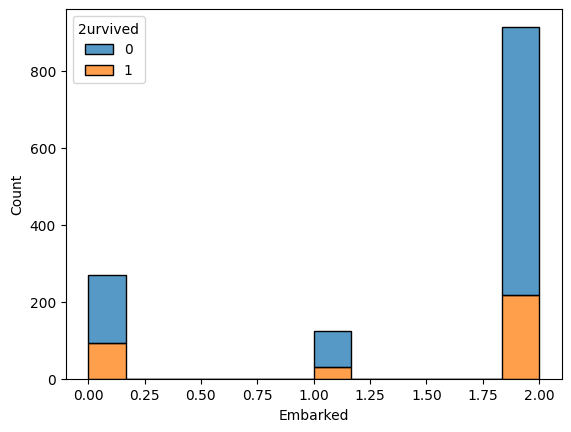

In [27]:
sns.histplot(data=df, x='Embarked', hue='2urvived', multiple='stack')

In [41]:
df = df.drop(columns='Embarked')

KeyError: "['Embarked'] not found in axis"

In [42]:
df

,Age,Fare,Sex,sibsp,Parch,Pclass,2urvived
0,22.0,7.2500,0,1,0,3,0
1,38.0,71.2833,1,1,0,1,1
2,26.0,7.9250,1,0,0,3,1
3,35.0,53.1000,1,1,0,1,1
4,35.0,8.0500,0,0,0,3,0
...,...,...,...,...,...,...,...
1304,28.0,8.0500,0,0,0,3,0
1305,39.0,108.9000,1,0,0,1,0
1306,38.5,7.2500,0,0,0,3,0
1307,28.0,8.0500,0,0,0,3,0


In [43]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['2urvived'])
y = df['2urvived']        

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=32,   
    stratify=y        
)

In [44]:
X_train.shape, X_val.shape
y_train.mean(), y_val.mean()

(np.float64(0.2617000955109838), np.float64(0.2595419847328244))

In [45]:
X_train.isnull().sum()

Age       0
Fare      0
Sex       0
sibsp     0
Parch     0
Pclass    0
dtype: int64

In [46]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression() 

model.fit(X_train, y_train)

preds = model.predict(X_val)

In [47]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy_score(y_val, preds)
confusion_matrix(y_val, preds)

array([[177,  17],
       [ 37,  31]])

In [48]:
accuracy_score(y_val, preds)

0.7938931297709924

In [107]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100,max_depth=5, random_state=40) 

model_rf.fit(X_train, y_train)

preds_rf = model_rf.predict(X_val)

In [108]:
accuracy_score(y_val, preds_rf)
confusion_matrix(y_val, preds_rf)

array([[174,  20],
       [ 36,  32]])

In [109]:
accuracy_score(y_val, preds_rf)

0.7862595419847328